In [1]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay as plot_cm
import matplotlib.pyplot as plt
import datetime as dt
import sys
from scipy.signal import medfilt
from pathlib import Path
sys.path.append(f"{Path.home()}/pavnet-v3/vlfcode/")
#sys.path.append("/home/aldo/maestria/tesis/vlf/code/")
from sxrf_download import sunpy_xrf
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
#xr_df = sunpy_xrf("2025-01-1 12:00", "2025-08-26 21:59", sat_number=18)
import hmmlearn
import modelutils as mu 
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression as mar



In [2]:


# df = pd.read_csv(...) 
df1 = pd.read_csv("vlf_trainingdata_2025_piu.csv", index_col=[0],parse_dates=[0])
df2 = pd.read_csv("vlf_test_2026_piu.csv", index_col=[0],parse_dates=[0])
#df2.rename(columns={"GOES-18_long": "GOES18"}, inplace=True)
df2.drop(columns=["GOES-18_long"], inplace=True)
#df2.columns = [ "NAA","GOES18" ,"state" ,"GOES19", "flare_class"]
_df2 = df2[ ["NAA","GOES18" ,"state" ,"GOES19"]]
_df1 = df1[ ["NAA","GOES18" ,"state" ,"GOES19"]]
#df = df1.join(df2[[ "NAA","GOES18" ,"GOES18" ,"state" ,"GOES19"]], how="left")
# Drop duplicate rows within each DataFrame (keep first occurrence per timestamp)
_df1 = _df1[~_df1.index.duplicated(keep='first')]
_df2 = _df2[~_df2.index.duplicated(keep='first')]

# Now concatenate and drop duplicates across the combined set
combined = pd.concat([_df1, _df2])
df = combined[~combined.index.duplicated(keep='first')]  # or keep='last'

In [3]:
df

,NAA,GOES18,state,GOES19
2024-12-17 00:00:00,NaN,NaN,0.0,0.000002
2024-12-17 00:01:00,NaN,NaN,0.0,0.000002
2024-12-17 00:02:00,NaN,NaN,0.0,0.000002
2024-12-17 00:03:00,NaN,NaN,0.0,0.000002
2024-12-17 00:04:00,NaN,NaN,0.0,0.000002
...,...,...,...,...
2026-04-08 23:55:00,NaN,0.000001,0.0,NaN
2026-04-08 23:56:00,NaN,0.000001,0.0,NaN
2026-04-08 23:57:00,NaN,0.000001,0.0,NaN
2026-04-08 23:58:00,NaN,0.000001,0.0,NaN


In [4]:
lowp = signal.firwin(101, 0.01, fs=1/10)
df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
#df['NAA_dB'] = 20 * np.log10(df['NAA-filt'] + 1e-9)
# derivada o velocidad de cambio

df.head()

df['NAA'] = df['NAA'].clip(lower=-10)
background = df['NAA'].rolling(window=60, center=False).min()
df["NAA_dB_bgrm"] = df["NAA"]-background #brackground removed
df['Delta'] = df['NAA'].diff(5).fillna(0)

/tmp/ipykernel_8846/1533647510.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
/tmp/ipykernel_8846/1533647510.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NAA'] = df['NAA'].clip(lower=-10)
/tmp/ipykernel_8846/1533647510.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.

In [5]:
df2.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'flare_class'], dtype='object')

In [6]:

df["time"] = df.index.time
df["date"] = df.index.date
pivotdf = df.pivot(values="NAA", columns="time", index="date")#.dropna()
pivot_qdc = pivotdf.rolling(window=27, center=True, min_periods=2).median()
# removing the QDC  mask
qdc_refcurve = pivot_qdc.unstack().swaplevel().sort_index()
qdc_refcurve.index = [dt.datetime.combine(qdc_refcurve.index[i][0], qdc_refcurve.index[i][1]) for i in range(len(qdc_refcurve))]
df["qdc_ref"] = qdc_refcurve
# Actualizacion: cambio de X, X= [delta(background removed) , diff(periods=5)]
df["delta_amp"] = df["NAA"] - df["qdc_ref"]
df['diff_amp'] = df['delta_amp'].diff(5).fillna(0)




/tmp/ipykernel_8846/1695552232.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time"] = df.index.time
/tmp/ipykernel_8846/1695552232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = df.index.date
/tmp/ipykernel_8846/1695552232.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

(29278080.0, 29280960.0)

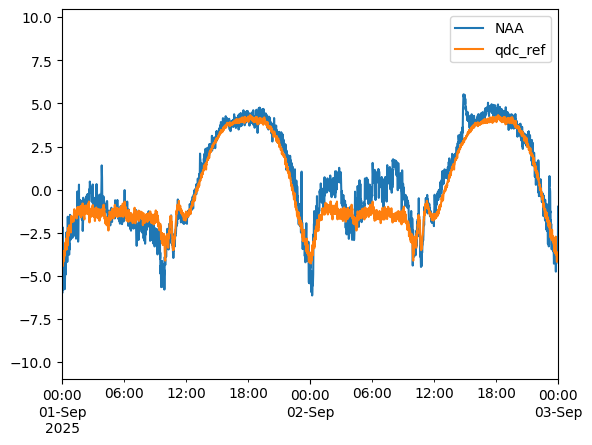

In [7]:
dl1,dl2 = dt.datetime(2025,9,1), dt.datetime(2025,9,3)
#df[["delta_amp","diff_amp"]].plot()

df[["NAA","qdc_ref"]].plot()
plt.xlim(dl1, dl2)
#plt.axvspan(rx_suntimes[dl1.date][0], color="yellow")
#plt.axvspan(*rx_suntimes[(dl2-dt.timedelta(days=1)).date()], color="yellow")

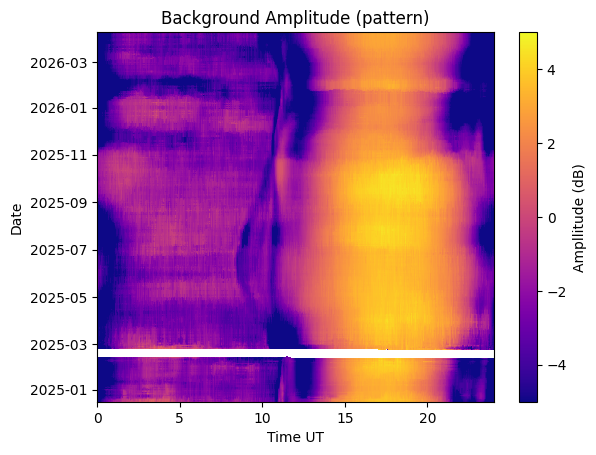

In [8]:

time_arr = np.linspace(0,24, len(pivot_qdc.columns))

fig, ax = plt.subplots()
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5,vmax=5)
ax.set_xlabel("Time UT")
ax.set_ylabel("Date")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Ampllitude (dB)")
ax.set_title("Background Amplitude (pattern)")
plt.show()



## Using ony diurnal times
based on the astronomical sunrise and sunset


In [9]:
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.time import Time

# Define observer locations
loc_tx = EarthLocation(lat=44.63678 * u.deg, lon=-67.27949 * u.deg)
loc_rx = EarthLocation(lat=-12.50423 * u.deg, lon=-76.79773 * u.deg)

# Solar elevation target angle:
#  -0.833° for standard horizon sunrise/sunset (includes atmospheric refraction)
# -18.000° for astronomical twilight (dawn/dusk)
TARGET_ALT = -0.833 


def get_sun_events(d, location, target_alt=-0.833):
    """Calculates event crossing times in UTC decimal hours using Astropy."""
    date_str = str(d)[:10]
    t0 = Time(f"{date_str} 00:00:00", scale="utc")
    times = t0 + np.linspace(0, 24, 1440) * u.hour  # 1-minute grid

    # Compute solar altitudes
    alts = (
        get_sun(times)
        .transform_to(AltAz(obstime=times, location=location))
        .alt.deg
    )
    diff = alts - target_alt

    # Detect zero-crossings
    sign_change = np.diff(np.sign(diff))
    rising_idx = np.where(sign_change > 0)[0]
    setting_idx = np.where(sign_change < 0)[0]

    return interpolate_hour(diff, rising_idx), interpolate_hour(diff, setting_idx)

def interpolate_hour(diff,idx_list):
    if len(idx_list) == 0:
        return np.nan  # Returns NaN if event doesn't occur (e.g., persistent twilight)
    i = idx_list[0]
    y0, y1 = diff[i], diff[i + 1]
    frac = -y0 / (y1 - y0)
    return (i + frac) * (24.0 / 1440.0)

# Execute loop
tx_sunrise, tx_sunset = [], []
rx_sunrise, rx_sunset = [], []
tx_suntimes = {}
rx_suntimes = {}

for d in pivot_qdc.index:
    print(f"{d}", end="\r")
    # Transmitter (TX - Maine)
    t0_tx, t1_tx = get_sun_events(d, loc_tx, target_alt=TARGET_ALT)
    tx_sunrise.append(t0_tx)
    tx_sunset.append(t1_tx)
    tx_suntimes[d] = [t0_tx, t1_tx]

    # Receiver (RX - Lima)
    t0_rx, t1_rx = get_sun_events(d, loc_rx, target_alt=TARGET_ALT)
    rx_sunrise.append(t0_rx)
    rx_sunset.append(t1_rx)
    rx_suntimes[d] = [t0_rx, t1_rx]

2026-04-08

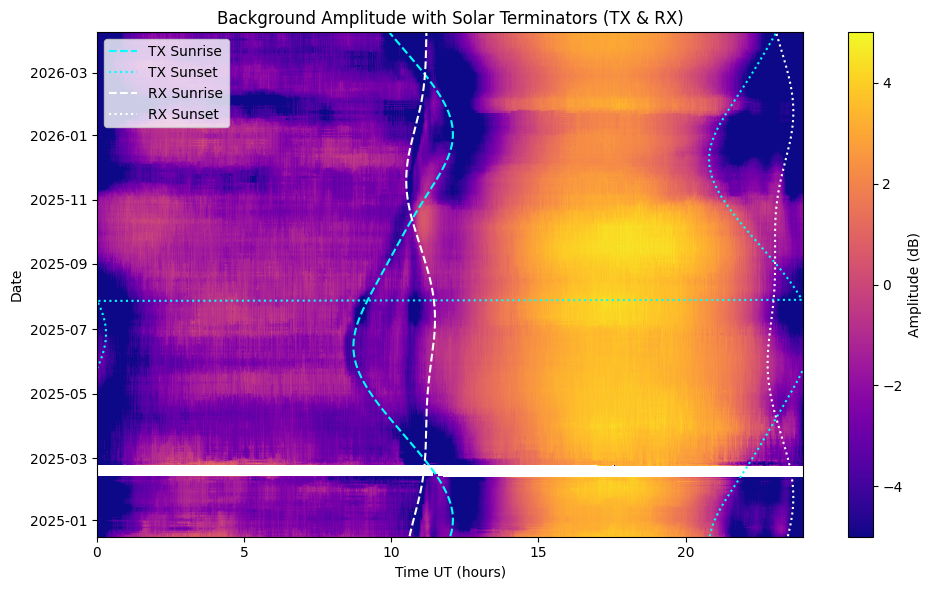

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))

# Mapa de calor de amplitud
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5, vmax=5)

# Curvas de Amanecer/Atardecer para TX y RX (X: hora decimal UT, Y: fechas)
ax.plot(tx_sunrise, pivot_qdc.index, color='cyan', linestyle='--', linewidth=1.5, label='TX Sunrise')
ax.plot(tx_sunset,  pivot_qdc.index, color='cyan', linestyle=':',  linewidth=1.5, label='TX Sunset')

ax.plot(rx_sunrise, pivot_qdc.index, color='white', linestyle='--', linewidth=1.5, label='RX Sunrise')
ax.plot(rx_sunset,  pivot_qdc.index, color='white', linestyle=':',  linewidth=1.5, label='RX Sunset')

# Formatos y etiquetas
ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Date")
ax.set_title("Background Amplitude with Solar Terminators (TX & RX)")
ax.set_xlim(0, 24)
ax.legend(loc='upper left', framealpha=0.8)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Amplitude (dB)")

plt.tight_layout()
plt.show()

In [11]:
plt.figure()
plt.plot(time_arr, pivot_qdc.loc[date(2025, 1, 1 ),:], color="k")
plt.vlines(rx_suntimes[date(2025, 1, 1 )],-10,4, ls="--", color="red", label="local")
plt.vlines(tx_suntimes[date(2025, 1, 1 )],-10,4, ls=":", color="blue", label="transmitter")
plt.legend()

NameError: name 'date' is not defined

<Figure size 640x480 with 0 Axes>

In [12]:

# 1. Extraer fechas y convertir la hora del index a hora decimal (UT)
fechas = df.index.date
horas = df.index.hour + df.index.minute / 60.0 + df.index.second / 3600.0

# 2. Mapear t0 (sunrise) y t1 (sunset) para cada fila del DataFrame
t0_vals = np.array([max([rx_suntimes[d][0], tx_suntimes[d][0]]) if d in rx_suntimes else np.nan for d in fechas])
t1_vals = np.array([max([rx_suntimes[d][1], tx_suntimes[d][1]]) if d in rx_suntimes else np.nan for d in fechas])

# 3. MÁSCARA BOOLEANA (True = Día, False = Noche)
mask_diurna = (horas >= t0_vals) & (horas <= t1_vals)

In [13]:
df_diurno = df[mask_diurna]


In [14]:
%matplotlib inline

(np.float64(20304.416666666668), np.float64(20305.0))

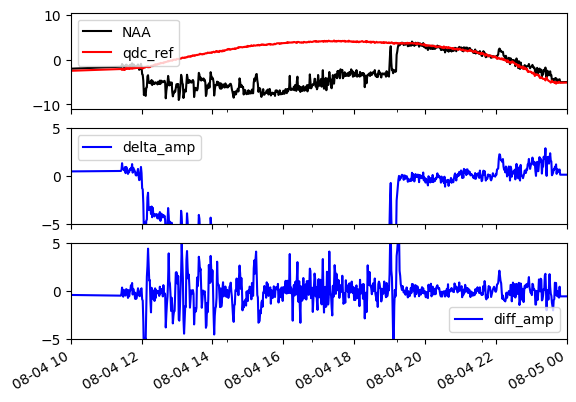

In [15]:
dl1,dl2 = dt.datetime(2025,8,4, 10), dt.datetime(2025,8,5)
#df[["delta_amp","diff_amp"]].plot()
fig = plt.figure()
ax = plt.subplot(311)
df_diurno[["NAA","qdc_ref"]].plot(color=["black", "red"], ax=ax)
#ax2 = ax.twinx()
#ax2.plot(df["GOES18"], color="purple")
#ax2.set_ylim(1e-7, 1e-3)
ax = plt.subplot(312, sharex=ax)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-5,5)
ax = plt.subplot(313, sharex=ax)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-5,5)
plt.xlim(dl1, dl2)


<Axes: ylabel='Frequency'>

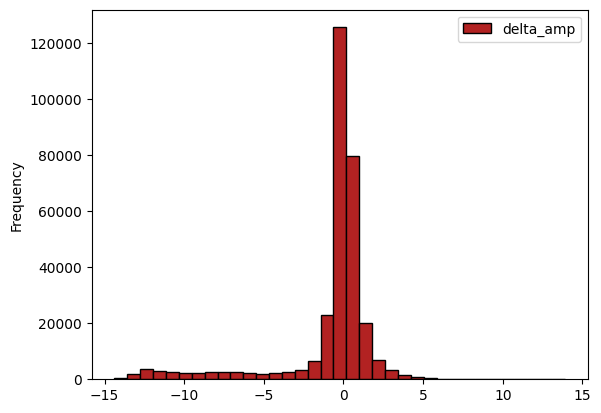

In [26]:
fig, ax = plt.subplots()
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")

In [75]:

dl1, dl2 = dt.datetime(2025, 12, 3), dt.datetime(2025, 12, 5)

# 1. Creación de subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 6
                                                   ), sharex=True)

# 2. Graficación de señales
df_diurno[["NAA", "qdc_ref"]].plot(color=["black", "red"], ax=ax1)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax2)
df_diurno[["Delta"]].plot(color=["green"], ax=ax2)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax3)

# 3. Mapeo de colores para cada estado {1, 2}
colores_estado = {
    1: ('red', 0.35, 'Onset (s=1)'),
    2: ('orange', 0.35, 'Decay (s=2)')
}

# 4. Aplicación de las bandas de color en todos los subplots
axes = [ax1, ax2, ax3]

for ax in axes:
    for estado, (color, alpha, label) in colores_estado.items():
        ax.fill_between(
            df_diurno.index, 0, 1,
            where=(df_diurno['state'] == estado),
            color=color, alpha=alpha,
            transform=ax.get_xaxis_transform(),
            step='mid'
        )

# Configuración final
ax1.set_xlim(dl1, dl2)
plt.tight_layout()
plt.show()

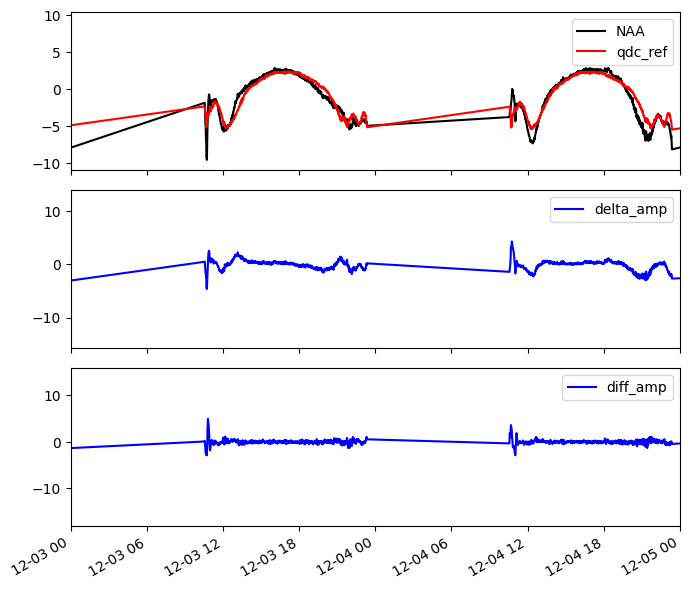

In [55]:
print("")

False

In [76]:
X = df_diurno[['delta_amp', 'diff_amp']].values
y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
t = df_diurno.index
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Cortamos al 80% del tiempo.
split_idx = int(len(X_scaled) * 0.8)

X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = t[:split_idx], t[split_idx:]
X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# Usamos los datos de TRAIN para definir qué es cada estado.

def calculate_mean_and_cov(features, labels):
    unique_labels = np.unique(labels)
    n_states = len(unique_labels)
    n_features = features.shape[1]
    
    means = np.zeros((n_states, n_features))
    covars = np.zeros((n_states, n_features, n_features))
    
    for i, state in enumerate(unique_labels):
        state_data = features[labels == state]
        means[i] = np.mean(state_data, axis=0)
        cov = np.cov(state_data.T)
        min_covar = 1e-4  # Valor pequeño para darle "volumen" a la gaussiana
        cov = cov + np.eye(n_features) * min_covar
        
        cov = (cov + cov.T) / 2
        covars[i] = cov
        
    return means, covars


def calculate_startprob(labels):

    n_states = len(np.unique(labels))
    startprob = np.zeros(n_states)

    initial_state = int(labels[0])
    startprob[initial_state] = 1.0

    return startprob
    
def calculate_transmat(labels):

    n_states = len(np.unique(labels))
    transmat = np.zeros((n_states, n_states))

    # 1. Contar todas las transiciones en la secuencia
    for i in range(len(labels) - 1):
        from_state = int(labels[i])
        to_state = int(labels[i+1])
        transmat[from_state, to_state] += 1

    row_sums = transmat.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        transmat = np.where(row_sums > 0, transmat / row_sums, 0)
    return transmat

# 
startprob = calculate_startprob(y_train)
transmat = calculate_transmat(y_train)
means, covars = calculate_mean_and_cov(X_train, y_train)


Train samples: 273007 | Test samples: 68252


In [77]:
print("Transition Matrix A:\n",transmat)

Transition Matrix A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]


In [80]:
model = hmm.GaussianHMM(
    n_components=3, 
    covariance_type="full", 
    # init_params="smc", # 
    init_params="smc",
    min_covar=1e-3, 
    n_iter=50,          # Le damos iteraciones para converger
    verbose=True
)

model.startprob_ = startprob
model.transmat_ = transmat
model.means_ = means
model.covars_ = covars

In [81]:
print("Afinando parámetros con algoritmo EM...")
model.fit(X_train)

print(f"Model Converged: {model.monitor_.converged}")

2026-09-14 17:10:17 - hmmlearn.base - WARNING: Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
2026-09-14 17:10:17 - hmmlearn.base - WARNING: Even though the 'means_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'm'


Afinando parámetros con algoritmo EM...


2026-09-14 17:10:18 - hmmlearn.base - WARNING: Even though the 'covars_' attribute is set, it will be overwritten during initialization because 'init_params' contains 'c'
         1 -619032.53189178             +nan
         2 -336763.31211334 +282269.21977844
         3 -280320.02785483  +56443.28425851
         4 -258226.95268303  +22093.07517180
         5 -252216.98036922   +6009.97231380
         6 -249469.17927993   +2747.80108929
         7 -248135.06967002   +1334.10960991
         8 -247703.66676652    +431.40290350
         9 -247570.41540507    +133.25136145
        10 -247515.31771274     +55.09769233
        11 -247490.63818143     +24.67953131
        12 -247479.71143300     +10.92674844
        13 -247473.26809351      +6.44333949
        14 -247468.53850267      +4.72959084
        15 -247465.39469034      +3.14381233
        16 -247463.57528096      +1.81940938
        17 -247462.62986809      +0.94541287
        18 -247462.14315914      +0.48670895
        19 -247461.

Model Converged: True


        25 -247461.59407790      +0.00727514


In [83]:
%matplotlib inline

Text(0.5, 1.0, 'Convergence')

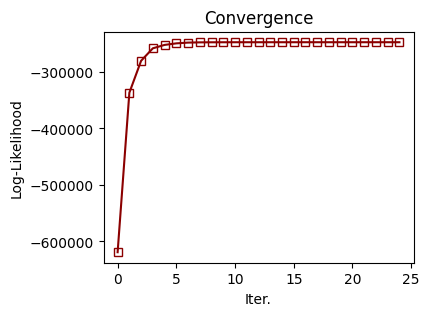

In [104]:
fig = plt.figure(figsize=(4,3))
plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
#model.monitor_.n_iter
plt.xlabel("Iter.")
plt.ylabel("Log-Likelihood")
plt.title("Convergence")

In [99]:
covars

array([[[0.79002063, 0.12765305],
        [0.12765305, 1.02013708]],

       [[0.24897105, 0.40760756],
        [0.40760756, 1.67904469]],

       [[0.24586773, 0.02702025],
        [0.02702025, 0.49700817]]])

In [112]:
model.means_

array([[ 0.43604125,  0.05210305],
       [-2.34437387, -0.03523481],
       [ 0.21899965, -0.00509184]])

In [115]:
for s in (0, 1, 2):
    m = y_train == s
    print(s, X_train[m].mean(axis=0), X_train[m].std(axis=0), m.sum())

0 [-0.02928716 -0.00302605] [0.88877309 1.00996691] 260363
1 [0.70630486 0.79298957] [0.4988113 1.2955891] 4266
2 [ 0.83025051 -0.30231769] [0.49572008 0.70487506] 8378


In [103]:
print("model transmat A:\n", model.transmat_ )
print("\ninitial transmat\n",transmat)

model transmat A:
 [[9.74094163e-01 2.59058372e-02 0.00000000e+00]
 [6.51255354e-03 9.60443522e-01 3.30439243e-02]
 [4.04273121e-03 3.89544458e-05 9.95918314e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]


In [105]:
# fig = plt.figure()
# ax = plt.subplot(211)
# plt.plot(model.means_, label="means") 
# plt.legend()
# ax = plt.subplot(212)
# ax.plot(model.covars_, label="covars")
# ax.legend()

In [106]:
#prediction
y_pred = model.predict(X_test)

In [87]:

def validate_match(true_intervals, pred_intervals, dfamp, amp_threshold):
    # Asumimos que true_intervals y pred_intervals están ordenados cronológicamente
    match_data = []
    print("True events:\t", len(true_intervals))
    print("Predicted events:\t", len(pred_intervals))
    for ref_r in true_intervals:
        # print(ref_r, len(pred_intervals))
        match = False
        
        # iterar evaluando sonbre las predicciones
        k = 0
        while k < len(pred_intervals):
            pred_r = pred_intervals[k]
            
            if pred_r[0].hour < 12 or pred_r[1].hour > 22 or dfamp.loc[pred_r[0]:pred_r[1]].mean() < amp_threshold:
                print("removed: " , pred_intervals.pop(k))
                continue 
            
            # check if match (overlap between intervals)
            if max([ref_r[0], pred_r[0]]) < min([ref_r[1], pred_r[1]]): 
                match = True
                # drop pred
                pred_intervals.pop(k) 
                
                match_data.append([*ref_r, *pred_r,1,1])
                continue 

            # pred is before the true ref : FP
            elif pred_r[1] < ref_r[0]: 
                # Es un evento predicho que left behind with no match
                match_data.append([np.nan, np.nan, *pred_r, 0,1])
                pred_intervals.pop(k)
                continue
            
            # pred is ahead of true ref
            elif ref_r[1] < pred_r[0]:
                break 
            
            k += 1

        # no match for true ref
        if not match:
            match_data.append([*ref_r, np.nan, np.nan, 1,0])
    # remained pred as FP
    for pred_r in pred_intervals:
         # filter by time and amp
         #if not (pred_r[0].hour < 12 or pred_r[1].hour > 22 or dfamp.loc[pred_r[0]:pred_r[1]].mean() < 4):
        if (pred_r[0].hour > 12 and pred_r[1].hour < 22 and dfamp.loc[pred_r[0]:pred_r[1]].mean() > amp_threshold):
            match_data.append([np.nan, np.nan, *pred_r, 0,1])
        else:
            print(f"Discarded FP : {pred_r}:: mean={dfamp.loc[pred_r[0]:pred_r[1]].mean() > amp_threshold}")
    matchdata = pd.DataFrame(match_data, columns=["t_true_1", "t_true_2", "t_pred_1", "t_pred_2", "true", "pred"])
    return matchdata


In [92]:
# processing the predicted states: grab time intervals
rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
# validate rise s=1 match - rise_true_intervals
matchdf_smooth = validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
print("\n", "--"*50)
print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
print("Nueva Matriz de Confusión:")
print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))

True events:	 90
Predicted events:	 228
removed:  [Timestamp('2026-01-05 12:06:00'), Timestamp('2026-01-05 21:40:00')]
removed:  [Timestamp('2026-01-05 22:10:00'), Timestamp('2026-01-05 22:48:00')]
removed:  [Timestamp('2026-01-05 23:11:00'), Timestamp('2026-01-05 23:14:00')]
removed:  [Timestamp('2026-01-08 23:13:00'), Timestamp('2026-01-08 23:16:00')]
removed:  [Timestamp('2026-01-09 22:07:00'), Timestamp('2026-01-09 22:56:00')]
removed:  [Timestamp('2026-01-09 23:03:00'), Timestamp('2026-01-09 23:06:00')]
removed:  [Timestamp('2026-01-10 23:18:00'), Timestamp('2026-01-10 23:21:00')]
removed:  [Timestamp('2026-01-12 12:12:00'), Timestamp('2026-01-12 21:45:00')]
removed:  [Timestamp('2026-01-12 22:07:00'), Timestamp('2026-01-12 22:38:00')]
removed:  [Timestamp('2026-01-13 23:32:00'), Timestamp('2026-01-13 23:35:00')]
removed:  [Timestamp('2026-01-14 14:04:00'), Timestamp('2026-01-14 15:05:00')]
removed:  [Timestamp('2026-01-14 22:05:00'), Timestamp('2026-01-15 12:04:00')]
removed:  [T

In [90]:
matchdf_smooth

,t_true_1,t_true_2,t_pred_1,t_pred_2,true,pred
0,NaT,NaT,2026-01-04 13:23:00,2026-01-04 13:26:00,0,1
1,NaT,NaT,2026-01-04 22:14:00,2026-01-04 22:17:00,0,1
2,2026-01-06 15:48:00,2026-01-06 16:01:00,2026-01-06 15:53:00,2026-01-06 15:56:00,1,1
3,2026-01-06 16:04:00,2026-01-06 16:13:00,NaT,NaT,1,0
4,NaT,NaT,2026-01-06 22:07:00,2026-01-07 12:07:00,0,1
...,...,...,...,...,...,...
228,NaT,NaT,2026-04-06 19:45:00,2026-04-06 19:48:00,0,1
229,NaT,NaT,2026-04-06 21:44:00,2026-04-06 21:47:00,0,1
230,2026-04-07 18:18:00,2026-04-07 18:32:00,NaT,NaT,1,0
231,NaT,NaT,2026-04-07 18:52:00,2026-04-07 18:55:00,0,1


In [45]:
%matplotlib qt

In [73]:
dl = [
    dt.datetime(2026, 1,1),
    dt.datetime(2026, 4, 10)
    ]

fig, axs = plt.subplots(2,1,sharex=True)
ax0 = axs[0]

#ax0.plot(t_test, X_test[:,0], color="gray", lw=1,label="Signal")
#ax0.plot(t_test, X_test[:,1], color="blue", lw=1, label="Diff. Signal")
ax0.plot(df["NAA"].loc[dl[0]:dl[1]], color="black", lw=1, label="Signal")
ax0.plot(df_diurno["delta_amp"].loc[dl[0]:dl[1]], color="navy", lw=1, label="Signal")
ax1 = ax0.twinx()
testmask = (dl[0]<t_test) & (t_test<dl[1])
ax1.plot(t_test[testmask], y_test[testmask], color="red", ls="--", lw=1.5, label="True state")
for t1,t2 in zip(matchdf_smooth["t_pred_1"], matchdf_smooth["t_pred_2"]):
    if not pd.isna(t1):
        ax1.axvspan(t1,t2, color="yellowgreen",alpha=0.6, label="Predicted event")
#plt.legend(l,"Predicted event")
ax0.set_ylabel("Amp. (dB)")

ax0.legend()
ax1.set_ylabel("State")
ax2 = axs[1]
ax2.plot(df['GOES18'].loc[dl[0]:dl[1]], color="purple",label="X rays GOES")
ax2.set_ylabel("Flux (W/m²)")
ax2.set_yscale("log")
ax2.set_xlabel("Time UT")
fig.autofmt_xdate()

In [57]:
plt.close()

In [107]:
print("true events", sum(np.diff(y_test==1) > 0))
print("pred events", sum(np.diff(y_pred==1) > 0))

true events 180
pred events 460


In [48]:
matchdf_smooth

,t_true_1,t_true_2,t_pred_1,t_pred_2,true,pred
0,NaT,NaT,2026-01-04 13:25:00,2026-01-04 13:28:00,0,1
1,NaT,NaT,2026-01-04 21:40:00,2026-01-04 21:46:00,0,1
2,NaT,NaT,2026-01-04 22:28:00,2026-01-04 22:31:00,0,1
3,NaT,NaT,2026-01-05 23:31:00,2026-01-06 12:07:00,0,1
4,NaT,NaT,2026-01-06 12:50:00,2026-01-06 12:53:00,0,1
...,...,...,...,...,...,...
372,NaT,NaT,2026-04-06 19:39:00,2026-04-06 19:42:00,0,1
373,NaT,NaT,2026-04-06 19:44:00,2026-04-06 19:47:00,0,1
374,NaT,NaT,2026-04-06 21:38:00,2026-04-06 21:58:00,0,1
375,NaT,NaT,2026-04-06 22:51:00,2026-04-06 22:58:00,0,1


In [57]:
plt.figure()
plt.plot(t_train, X_train)
plt.legend()

/tmp/ipykernel_8846/1644147617.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [111]:
%matplotlib qt
plt.figure()
ax = plt.subplot()
ax.plot(t_test, df_diurno.loc[t_test, "NAA"], color="black")
ax2 = ax.twinx()
ax2.plot(t_test,y_test, color="forestgreen", alpha=0.75)
ax2.plot(t_test,y_pred, color="red", alpha=0.7)

plt.show()